In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
import pandas as pd

In [20]:
df = pd.read_hdf('../../dataset_complete/BDT/BDT_all.h5', key='data')

beta1 = df['ang_median']

energy = df['RecoEnergy'][~np.isnan(beta1)]
label = df['Label'][~np.isnan(beta1)][(energy >= 0)&(energy<=10)]
beta1 = df['ang_median'][~np.isnan(beta1)][(energy >= 0)&(energy<=10)]

boolCC = (label == 1)
boolNC = (label == 0)

beta1_CC = beta1[boolCC]
beta1_NC = beta1[boolNC]

(array([0.00433535, 0.00763613, 0.00886777, 0.01113397, 0.01473034,
        0.01719361, 0.01990321, 0.02409076, 0.02576579, 0.03093865,
        0.0341409 , 0.03665343, 0.03990495, 0.04399397, 0.04783667,
        0.04852639, 0.05227055, 0.05729562, 0.05926624, 0.0644391 ,
        0.06631118, 0.07177964, 0.07621352, 0.07971136, 0.08478569,
        0.08724896, 0.09409685, 0.09572261, 0.09739763, 0.10503376,
        0.11035442, 0.11872953, 0.12074941, 0.1301591 , 0.13474078,
        0.1438056 , 0.14720491, 0.15124467, 0.16040803, 0.1705567 ,
        0.18750398, 0.18922827, 0.20390935, 0.20991972, 0.22612803,
        0.23253253, 0.24046425, 0.26430869, 0.27233894, 0.285345  ,
        0.31446083, 0.32032341, 0.3384038 , 0.36392326, 0.38476251,
        0.39377807, 0.42540643, 0.44102355, 0.47427768, 0.49437795,
        0.53068652, 0.55847219, 0.59083953, 0.62581794, 0.66759497,
        0.69646448, 0.73361056, 0.77868837, 0.81140057, 0.86012402,
        0.90554669, 0.95781724, 1.01048192, 1.05

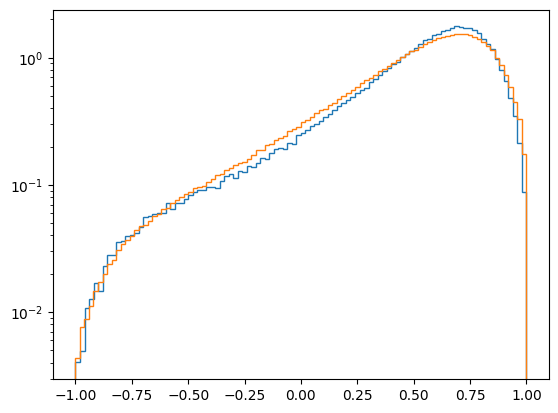

In [21]:
plt.hist(beta1[boolCC], bins=100, histtype='step', density=True, log=True)
plt.hist(beta1[boolNC], bins=100, histtype='step', density=True, log=True)

In [24]:
beta_threshold = np.arange(min(beta1), max(beta1)+0.00035, 0.00035) #np.arange(min(beta1), max(beta1)+1, 1)#np.arange(min(beta1), max(beta1)+0.00035, 0.00035) #np.arange(min(beta1), max(beta1)+0.1, 0.1) #
print(len(beta_threshold))

5716


In [25]:
fpr = []
tpr = []

y_true = label
y_prob = beta1

count = 0
for threshold in beta_threshold:

    if count % 100 == 0:
        print(count)
    count += 1

    y_pred = np.where((y_prob >= threshold), 1, 0)
                      
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tp = np.sum((y_pred == 1) & (y_true == 1))

    fn = np.sum((y_pred == 0) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))

    fpr.append(fp / (fp + tn))
    tpr.append(tp / (tp + fn))


fpr = np.array(fpr)
tpr = np.array(tpr)

# Sort by FPR in case they're not
sorted_indices = np.argsort(fpr)
fpr = fpr[sorted_indices]
tpr = tpr[sorted_indices]

# Compute AUC using trapezoidal rule
auc = np.trapz(tpr, fpr)
print(f"AUC = {auc:.2f}")

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
AUC = 0.52


Text(0, 0.5, 'True Positive Rate')

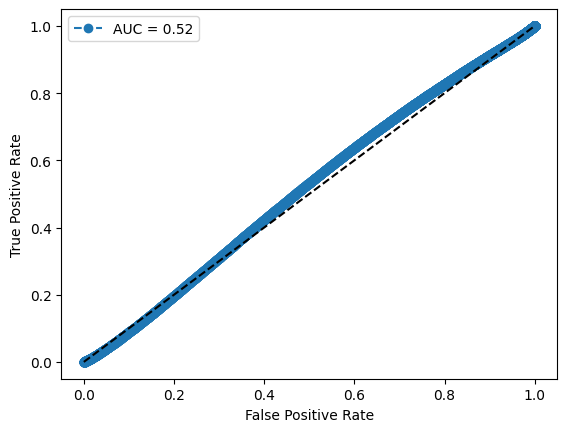

In [26]:
plt.plot(fpr, tpr, 'o--', label = f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

In [27]:
precision = []
recall = []

y_true = label
y_prob = beta1

count = 0
for threshold in beta_threshold:

    if count % 100 == 0:
        print(count)
    count += 1

    y_pred = np.where(y_prob >= threshold, 1, 0)
    
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tp = np.sum((y_pred == 1) & (y_true == 1))

    fn = np.sum((y_pred == 0) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))

    precision.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)
    recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)

baseline = len(beta1_CC)/(len(beta1_CC) + len(beta1_NC))
print(baseline)

precision = np.array(precision)
recall = np.array(recall)

# Sort by FPR in case they're not
sorted_indices = np.argsort(recall)
precision = precision[sorted_indices]
recall = recall[sorted_indices]

# Compute AUC using trapezoidal rule
auc_pr = np.trapz(precision, recall)
print(f"AUC = {auc_pr:.2f}")

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
0.20458695464769086
AUC = 0.21


Text(0, 0.5, 'Precision')

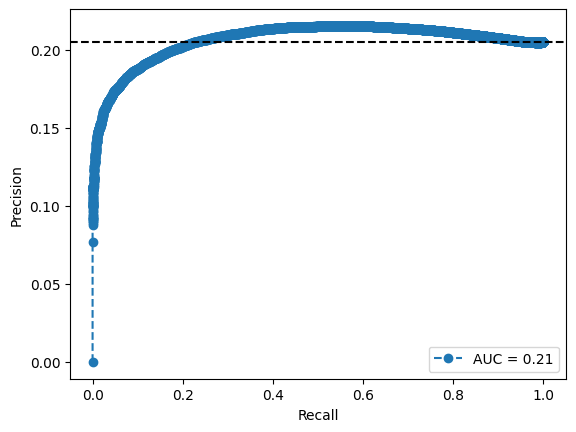

In [28]:
plt.plot(recall[precision < 1], precision[precision < 1], 'o--', label = f'AUC = {auc_pr:.2f}')
plt.axhline(y=baseline, c='k', ls='--')
plt.legend()
plt.xlabel('Recall')
plt.ylabel('Precision')

Text(0, 0.5, 'Precision')

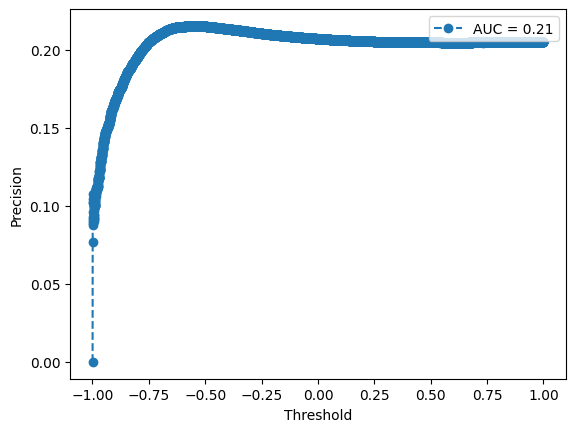

In [29]:
best_thresh = beta_threshold[precision<1][precision[precision<1] == max(precision[precision<1])]

plt.plot(beta_threshold[precision<1], precision[precision<1], 'o--', label = f'AUC = {auc_pr:.2f}')
#plt.axvline(x=best_thresh, c='k', ls='--', )#label = f'best threshold = {best_thresh:.2f}')
plt.legend()
plt.xlabel('Threshold')
plt.ylabel('Precision')

In [16]:
beta_threshold[precision<1][precision[precision<1] >= 0.251]

array([-0.66536291, -0.66501291, -0.66466291, -0.66431291, -0.66396291,
       -0.66361291, -0.66326291, -0.66291291, -0.66256291, -0.66221291,
       -0.66186291, -0.66151291, -0.66116291, -0.66081291, -0.66046291,
       -0.66011291, -0.65976291, -0.65941291, -0.65906291, -0.65871291,
       -0.65836291, -0.65801291, -0.65766291, -0.65731291, -0.65696291,
       -0.65661291, -0.65626291, -0.65591291, -0.65556291, -0.65521291,
       -0.65486291, -0.65451291, -0.65416291, -0.65381291, -0.65346291,
       -0.65311291, -0.65276291, -0.65241291, -0.65206291, -0.65171291,
       -0.65136291, -0.65101291, -0.65066291, -0.65031291, -0.64996291,
       -0.64961291, -0.64926291, -0.64891291, -0.64856291, -0.64821291,
       -0.64786291, -0.64751291, -0.64716291, -0.64681291, -0.64646291,
       -0.64611291, -0.64576291, -0.64541291, -0.64506291, -0.64471291,
       -0.64436291, -0.64401291, -0.64366291, -0.64331291, -0.64296291,
       -0.64261291, -0.64226291, -0.64191291, -0.64156291, -0.64

In [19]:
max(precision[precision<1])

0.255340927291685

Text(0.5, 0, 'median time residual')

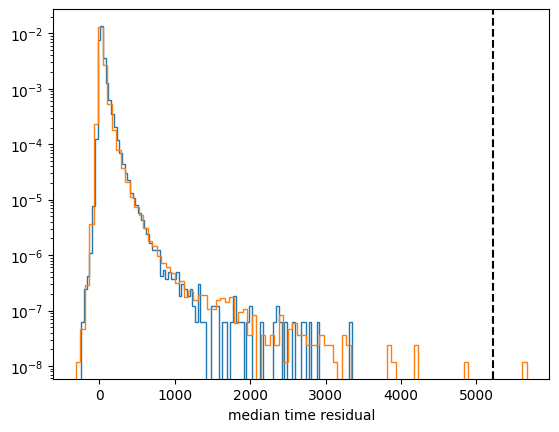

In [12]:
plt.hist(beta1[boolCC], bins=100, histtype='step', density=True, log=True)
plt.hist(beta1[boolNC], bins=100, histtype='step', density=True, log=True)
plt.axvline(x=best_thresh, c='k', ls='--')
plt.xlabel('median time residual')